In [2]:
from time import perf_counter

from inspect import getsourcefile
from io import TextIOWrapper
from math import ceil, floor
from pathlib import Path
from typing import Callable, List, Union, overload

import numpy as np
from Tools.demo.sortvisu import steps
from daceypy import DA, array
from daceypy.op import cos, sin, sqr, sqrt, vnorm
from numpy.typing import NDArray
from matplotlib import pyplot as plt

In [3]:
#Ex6.6.1    mid-point integrator using DA (x_n+1) = x_n + h * f(x_n + h/2 * f(x_n, t_n), t_n + h/2)

def mid_point(x0: Union[array,float], t0: float, t1: float, f):
    hmax = 0.005
    steps = ceil((t1 - t0) / hmax)                 # Number of steps between the two times
    t = t0
    x = x0.copy()

    for i in range(steps):
        x += hmax*f(x + hmax/2*(f(x,t)), t + hmax/2)
        t += hmax

    return x






In [4]:
# Rk4

def rk4(x0: Union[array,np.array], t0: float, t1: float, f):
    hmax = 0.01
    steps = ceil((t1 - t0) / hmax)                 # Number of steps between the two times
    t = t0
    x = x0.copy()

    for _ in range(steps):
        k1 = f(x,t)
        k2 = f(x + hmax*k1/3, t + hmax/3)
        k3 = f(x + hmax*(-k1/3 + k2), t + 2*hmax/3)
        k4 = f(x + hmax*(k1 - k2 + k3), t + hmax)

        x += hmax*(k1 + 3*k2 + 3*k3 + k4)/8
    return x

In [7]:
#Ex 6.1.2 Pendulum ODE
def pendulumRHS(x: Union[NDArray,array], t: float) -> Union[NDArray,array]:
    # pendulum cons tants
    L = 0.61       # m
    m = 0.21       # kg
    M = 0.4926     # kg
    g = 9.81       # kg*m/s^2

    sint = sin(x[0])
    cost = cos(x[0])

    return np.array([
        x[1],
        ((M+m)*g*sint-m*L*sqr(x[1])*sint*cost)/((M+m)*L+m*L*sqr(cost)),
    ]).view(type(x))

DA.init(30,2)
#Real number example
x0 = np.array([0.0,0.2])  #columns as states and rows as timesteps
t0 = 0
dt = 0.05
tf = 10
steps = floor(tf/dt)
# make empty arrays for plotting
x_real = np.zeros((steps,2))


t = np.zeros((steps,1))
t[0,:] = t0
x_real[0,:] = x0

for i in range(1,steps):
    x1 = rk4(x0, t0, t0 + dt, pendulumRHS)
    #reset variables
    t0 = t0 + dt
    x0 = x1
    x_real[i,:] = x1
    t[i,:] = t0

#DA example - need to think of a way to get a 2D DA array
x_DA_solutions = [array([0.0, 0.0 + 0.0*DA(1)]) for _ in range(steps)]
x_DA_solutions[0] = array([0.0, 0.2 + 0.04*DA(1)])
t0 = 0
dt = 0.05
t_DA = np.zeros((steps,1))
t_DA[0,:] = t0

for i in range(1,steps):
    x1 = rk4(x_DA_solutions[i-1], t0, t0 + dt, pendulumRHS)
    t0 = t0 + dt
    x0 = x1

    x_DA_solutions[i] = x1
    t_DA[i,:] = t0

#evaluate the DA solution and store in numpy array for plotting

x_DA_minus = np.zeros((steps,2))
x_DA_nominal = np.zeros((steps,2))
x_DA_plus = np.zeros((steps,2))

for i in range(len(x_DA_solutions)):
    x_DA_minus[i,:] = x_DA_solutions[i].eval([-0.0,-10.0])
    x_DA_nominal[i,:] = x_DA_solutions[i].eval([0.0,0.0])
    x_DA_plus[i,:] = x_DA_solutions[i].eval([0.0,10.0])
    print(i)

#Plots: make 2 plots, one for real and one for DA. The columns are states and the rows are timesteps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(t, x_real[:,0], label="Real Angle")
ax1.plot(t,x_real[:,1],label="Real Angular Velocity")
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('State')
ax1.legend()
ax1.grid()


ax2.plot(t_DA, x_DA_minus[:,0], ls='--',label="DA Angle -1")
ax2.plot(t_DA, x_DA_minus[:,1], ls='--', label="DA Angular Rate -1")
ax2.plot(t_DA, x_DA_nominal[:,0], label="DA Angle 0")
ax2.plot(t_DA, x_DA_nominal[:,1], label="DA Angular Rate 0")
ax2.plot(t_DA, x_DA_plus[:,0], ls='--', label="DA Angle +1")
ax2.plot(t_DA, x_DA_plus[:,1], ls='--', label="DA Angle +1")
ax2.set_xlabel('Time(s)')
ax2.set_ylabel('State')
ax2.set_ylim([-10, 25])
ax2.legend()
ax2.grid()

# Dynamics problem - the angles and angle rates are positive at all times (could be a problem with the dynamics function rather than the DA implimentation

KeyboardInterrupt: 

In [6]:
#Ex 6.1.3: I dont understand
#Ex 6.1.3
def f(x: Union[NDArray,array], t: float) -> Union[NDArray,float]:
    alpha = 0
    f = (1 + alpha * x.vnorm()) * array([-x[1],x[0]])
    return f

#Intialise DA
DA.init(15,2)
x = array([2.0 + DA(1), DA(2)])
#Propagation loop
t0 = 0
tf = 2*np.pi
dt = 2*np.pi/6
steps = floor(tf/dt)
N = 7                   #Grid density


#State Propagation and store polynomials
t = t0
for k in range(steps):
    x0 = rk4(x0,t0,t0+dt,f)
    t += dt
    result[:,:,k] = sample(x0, t0, N)


# Modified initialization - timesteps as the last dimension
x_DA = np.zeros((2*N+1, 2*N+1, 2, steps))  # (x-grid, y-grid, components, time)

for k in range(steps):
    for i in range(-N, N+1):
        for j in range(-N,N+1):
            args = np.array([0.0,0.0])
            args[0] = i / N
            args[1] = j / N
            x_result = x_solutions[k].eval(args)

            # Store both components of the result at timestep k
            x_DA[i+N,j+N,:,k] = x_result  # Now storing both x and y components for timestep k

# Create plotting code
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Create a mesh grid for plotting
x_grid = np.linspace(-1, 1, 2*N+1)
y_grid = np.linspace(-1, 1, 2*N+1)
X, Y = np.meshgrid(x_grid, y_grid)

# Create two visualizations: animation and static subplots
# 1. Animated plot
fig_anim, ax_anim = plt.subplots(figsize=(10, 10))

def update(frame):
    ax_anim.clear()
    ax_anim.quiver(X, Y, x_DA[:,:,0,frame], x_DA[:,:,1,frame])
    ax_anim.set_title(f'Time step {frame}')
    ax_anim.set_xlim([-1.5, 1.5])
    ax_anim.set_ylim([-1.5, 1.5])
    ax_anim.grid(True)
    ax_anim.set_aspect('equal')

anim = FuncAnimation(fig_anim, update, frames=steps, interval=200)
plt.show()

# 2. Static subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()

# Plot six different timesteps
plot_steps = np.linspace(0, steps-1, 6, dtype=int)
for idx, timestep in enumerate(plot_steps):
    axs[idx].quiver(X, Y, x_DA[:,:,0,timestep], x_DA[:,:,1,timestep])
    axs[idx].set_title(f'Time step {timestep}')
    axs[idx].set_xlim([-1.5, 1.5])
    axs[idx].set_ylim([-1.5, 1.5])
    axs[idx].grid(True)
    axs[idx].set_aspect('equal')

plt.tight_layout()
plt.show()

OSError: exception: access violation reading 0x000001C6AD706BF0

The take away here is that the domain becomes really skewed the further you propagate it. This means the the errors in the solution in crease and the bounds the taylor series polynomail increase. For a subsquent observation this means that a larger area of sky to look at.

In [7]:
#ex 6.4 Derive an STM using dynmaics in f
def f(x: Union[NDArray,array], t: float) -> Union[NDArray,float]:
    alpha = 0
    f = (1 + alpha * x.vnorm()) * array([-x[1],x[0]])
    return f

x = array([1 + DA(1), 1 + DA(2)])
xf = rk4(x, 0, 2*np.pi,f)

print(f"{x[0].deriv(1).cons()}  {x[0].deriv(2).cons()}")                        #STM is the d(x_f)/d(x_0) so just do the deriviative .deriv(1) means take derivative wrt to first variable, .derive(2) means second variable

print(f"{x[1].deriv(1).cons()}  {x[1].deriv(2).cons()}\n")
STM = np.array([[x[0].deriv(1).cons(), x[0].deriv(2).cons()], [x[1].deriv(1).cons(),x[1].deriv(2).cons()]])

print(f"The State Trnasition Matrix is:\n{STM}\n")

1.0  0.0
0.0  1.0

The State Trnasition Matrix is:
[[1. 0.]
 [0. 1.]]



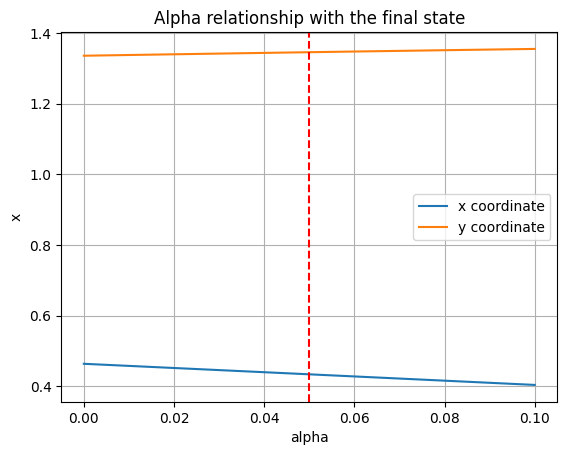

In [8]:
#Ex 6.1.5 fix intial conditions to [1,1]. Set alpha as DA parameter within interval [0, 0.1] and compute final state at tf = 2pi as a function of alpha

#Propagate the nomial solution
#Sample around the propagated solution from [0, 0.1] to see how x varies with alpha

def f(x: Union[NDArray,array], t: float) -> Union[NDArray,float]:
    alpha = 0.05 + 0.05*DA(1)
    f = (1 + alpha * x.vnorm()) * array([-x[1],x[0]])
    return f

x = array([1.0, 1.0])
xf = rk4(x, 0, 2*np.pi,f)

#evalute the taylor polynomial around the nomial solution
N = 5
xf_solutions = np.zeros((2,2*N))  #Initialise vector to store solutions in
sample_points = np.linspace(0, 0.1, 2*N)  # Create evenly spaced points from 0 to 0.1

for i in range(2*N):         #Create vector to sample around the solution
    xf_solutions[0,i] = xf[0].evalScalar(sample_points[i])
    xf_solutions[1,i] = xf[1].evalScalar(sample_points[i])

#Plot to visualise relationship
plt.plot(sample_points, xf_solutions[0,:], label="x coordinate")
plt.plot(sample_points, xf_solutions[1,:], label="y coordinate")
plt.axvline(x=0.05, color='r', linestyle='--')
plt.xlabel("alpha")
plt.ylabel("x")
plt.title("Alpha relationship with the final state")
plt.legend()
plt.grid(True)



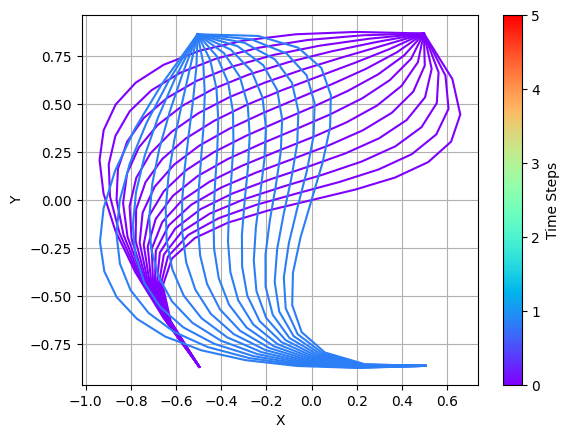

In [14]:
                                                                    #New code only stores #ex 6.2.2
def f(x: Union[NDArray,array], t: float) -> Union[NDArray,float]:
    alpha = 0.0
    f = (1 + alpha * x.vnorm()) * array([-x[1],x[0]])
    return f

def sample(x: array, t: float, N: int ) -> NDArray:

    res = np.array([]).reshape(0, 2)  # Empty array with 2 columns
    arg = np.array([0.0,0.0])
    for i in range(-N, N+1):
        arg[0] = i / N
        for j in range(-N,N+1):
            arg[1] = j / N
            row = x.eval(arg)
            res = np.vstack((res, row))

    return res


# set domain to [-1,1] for ease of computation. This means the array just has DAs as the midpoint in the domain is [0,0]
DA.init(10,2)
x = DA(1)
y = DA(2)
x0 = array([x, ((1.0-x*x)*(y + 1.0) + (x*x*x - x)*(1 - y))/2.0  ]) #initial state
#DA(1) is dx and DA(2) is dy. Want to propagate the nomial solution, therefore, find the dy that satsifies the constraints
# y =< 1 - x**2, y>= x**3 - x. Good first guess is interpolating between the two points.

#Propagate initial conditions to 2*pi
t0 = 0
dt = 2*np.pi/6
tf = 2*np.pi
steps = floor(tf/dt)

N = 7


result = np.zeros((((2*N)+1)**2, 2, steps))

for k in range(steps):                            #Propagate nomial polynomial forward
    x0 = mid_point(x0,t0,t0+dt,f)
    t0 += dt
    # obtained nomial polynomial at time t. Now sample around the polynomial to get set at that point and store
    result[:,:,k] = sample(x0, t0, N)




# Create a mesh grid for plotting

# Create figure and axes
fig, ax = plt.subplots()

# Plot your data
for k in range(2):
    grid_x = result[:,0,k].reshape((2*N+1, 2*N+1))
    grid_y = result[:,1,k].reshape((2*N+1, 2*N+1))
    ax.plot(grid_x, grid_y, color=plt.cm.rainbow(k/steps))

# Create the colorbar
norm = plt.Normalize(0, steps-1)
sm = plt.cm.ScalarMappable(cmap=plt.cm.rainbow, norm=norm)
sm.set_array([])  # Required for the colorbar
plt.colorbar(sm, ax=ax, label='Time Steps')

# Add other plot elements
ax.grid(True)
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

In [1]:
#Ex6.2.3
def CR3BP(x: Union[NDArray,array], t: float) -> array:
    mu = 0.30404234*10**(-5)
    pos: array = x[:3]
    vel: array = x[3:]
    acc: array = []
    r1 = sqrt(pos[1]**2 + pos[2]**2 + (pos[0] + mu)**2)
    r2 = sqrt(pos[1]**2 + pos[2]**2 + (-1 + pos[0] +mu)**2)

    acc_x = 2*vel[1] + pos[0] - ((1 - mu)*(pos[0] + mu))/(r1**3) - (mu*(-1 + pos[0] + mu))/(r2**3)
    acc.append(acc_x)

    acc_y = -2*vel[0] + pos[1] - ((1-mu)*pos[1])/(r1**3) - (mu*pos[1]) / (r2**3)
    acc.append(acc_y)

    acc_z = -(1 - mu)*pos[2]/(r1**3) - (mu*pos[2])/(r2**3)
    acc.append(acc_z)

    dx = vel.concat(acc)
    return dx

DA.init(10,6)
x0 = array.identity(6)
x0[0] = 0.9888426847
x0[2] = 0.0011210277
x0[4] = 0.0090335498
T = 3.05923

#STM is a first order compution
DA.pushTO(1)

xf = rk4(x,0,T,CR3BP)   #propagate to tf

for i in range(6):
    for j in range(1,7):
        print(x[i].deriv(j).cons())

DA.popTO()




SyntaxError: expected ':' (2184608193.py, line 34)